# SUMO Munich/Muncgin 5-UE Radio Metrics Monitor

This notebook builds or reuses a small SUMO scenario from `city_senario/Muncgin_map.osm`, tracks 5 SUMO vehicles as UEs with mixed slices, advances the multi-gNB radio simulator with `env.step(0)`, and plots radio/service metrics.

Slice plan for the 5 tracked UEs: `eMBB, eMBB, URLLC, URLLC, mMTC`. The current repo treats mobile mMTC differently from eMBB/URLLC scheduling, so the mMTC UE is useful for radio/link monitoring but may receive `allocated_prbs = 0` until mobile mMTC scheduling is implemented.


In [1]:
from pathlib import Path
import json
import math
import shutil
import subprocess
import sys
import xml.etree.ElementTree as ET

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "multi_gnb_wrapper.py").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import matplotlib.pyplot as plt

from scenario_creator import create_multignb_env
from sumo_wrapper import SumoMobilityWrapper

print("Project root:", PROJECT_ROOT)
for module_name in ["traci", "sumolib"]:
    try:
        __import__(module_name)
        print(module_name, "OK")
    except ModuleNotFoundError as exc:
        raise ModuleNotFoundError(
            f"{module_name} is required. Run: ./venv/bin/pip install traci sumolib"
        ) from exc


Project root: /home/oussama/Desktop/RL_juin
traci OK
sumolib OK


## Build Or Reuse The SUMO Scenario


In [2]:
OSM_PATH = PROJECT_ROOT / "city_senario" / "Muncgin_map.osm"
SCENARIO_DIR = PROJECT_ROOT / "scenario" / "mobility" / "muncgin_demo"
NET_PATH = SCENARIO_DIR / "muncgin.net.xml"
ROUTE_PATH = SCENARIO_DIR / "vehicles.rou.xml"
SUMOCFG_PATH = SCENARIO_DIR / "sim.sumocfg"
LAYOUT_PATH = SCENARIO_DIR / "gnb_layout.json"

SUMO_TOOLS = Path("/usr/share/sumo/tools")
OSM_BUILD = SUMO_TOOLS / "osmBuild.py"
RANDOM_TRIPS = SUMO_TOOLS / "randomTrips.py"

def run(cmd):
    print(" ".join(str(part) for part in cmd))
    subprocess.run([str(part) for part in cmd], check=True, cwd=PROJECT_ROOT)

def write_sumocfg():
    SUMOCFG_PATH.write_text(
        """<?xml version=\"1.0\" encoding=\"UTF-8\"?>
<configuration>
    <input>
        <net-file value=\"muncgin.net.xml\"/>
        <route-files value=\"vehicles.rou.xml\"/>
    </input>
    <time>
        <begin value=\"0\"/>
        <end value=\"180\"/>
        <step-length value=\"1.0\"/>
    </time>
</configuration>
""",
        encoding="utf-8",
    )

def write_layout(n_gnbs=4, prbs_per_gnb=120):
    root = ET.parse(NET_PATH).getroot()
    loc = root.find("location")
    x_min, y_min, x_max, y_max = [float(v) for v in loc.get("convBoundary").split(",")]
    width = max(x_max - x_min, 1.0)
    height = max(y_max - y_min, 1.0)
    positions = [
        [x_min + 0.25 * width, y_min + 0.25 * height],
        [x_min + 0.75 * width, y_min + 0.25 * height],
        [x_min + 0.25 * width, y_min + 0.75 * height],
        [x_min + 0.75 * width, y_min + 0.75 * height],
    ][:n_gnbs]
    radius = 0.42 * max(width, height)
    layout = {
        "city": "muncgin_demo",
        "source_osm": str(OSM_PATH.relative_to(PROJECT_ROOT)),
        "sumo_config_path": str(SUMOCFG_PATH.relative_to(PROJECT_ROOT)),
        "sumo_net_path": str(NET_PATH.relative_to(PROJECT_ROOT)),
        "gnb_positions": [[round(x, 3), round(y, 3)] for x, y in positions],
        "coverage_radius": [round(radius, 3)] * len(positions),
        "carrier_ids": [0] * len(positions),
        "max_prbs_per_gnb": [int(prbs_per_gnb)] * len(positions),
    }
    LAYOUT_PATH.write_text(json.dumps(layout, indent=2), encoding="utf-8")
    return layout

def ensure_sumo_scenario(force=False):
    if force and SCENARIO_DIR.exists():
        shutil.rmtree(SCENARIO_DIR)
    SCENARIO_DIR.mkdir(parents=True, exist_ok=True)
    osm_copy = SCENARIO_DIR / "muncgin_bbox.osm.xml"
    if not osm_copy.exists():
        shutil.copy2(OSM_PATH, osm_copy)
    if not NET_PATH.exists():
        run([sys.executable, OSM_BUILD, "--osm-file", osm_copy, "--prefix", "muncgin", "--output-directory", SCENARIO_DIR, "--vehicle-classes", "road"])
    if not ROUTE_PATH.exists():
        run([sys.executable, RANDOM_TRIPS, "--net-file", NET_PATH, "--route-file", ROUTE_PATH, "--output-trip-file", SCENARIO_DIR / "vehicles.trips.xml", "--begin", 0, "--end", 20, "--period", 1, "--seed", 42, "--validate", "--vehicle-class", "passenger", "--prefix", "ue"])
    write_sumocfg()
    layout = write_layout()
    return layout

layout = ensure_sumo_scenario(force=False)
route_root = ET.parse(ROUTE_PATH).getroot()
vehicle_ids = [v.get("id") for v in route_root.findall("vehicle")]
print("SUMO config:", SUMOCFG_PATH)
print("Vehicles in route file:", len(vehicle_ids), vehicle_ids[:10])
print("gNB layout:", layout)
assert len(vehicle_ids) >= 5, "Need at least 5 valid SUMO routes"


SUMO config: /home/oussama/Desktop/RL_juin/scenario/mobility/muncgin_demo/sim.sumocfg
Vehicles in route file: 15 ['ue0', 'ue1', 'ue2', 'ue5', 'ue6', 'ue7', 'ue8', 'ue9', 'ue11', 'ue13']
gNB layout: {'city': 'muncgin_demo', 'source_osm': 'city_senario/Muncgin_map.osm', 'sumo_config_path': 'scenario/mobility/muncgin_demo/sim.sumocfg', 'sumo_net_path': 'scenario/mobility/muncgin_demo/muncgin.net.xml', 'gnb_positions': [[739.485, 421.692], [2218.455, 421.692], [739.485, 1265.077], [2218.455, 1265.077]], 'coverage_radius': [1242.335, 1242.335, 1242.335, 1242.335], 'carrier_ids': [0, 0, 0, 0], 'max_prbs_per_gnb': [120, 120, 120, 120]}


## Plot The Munich/Muncgin Road Network


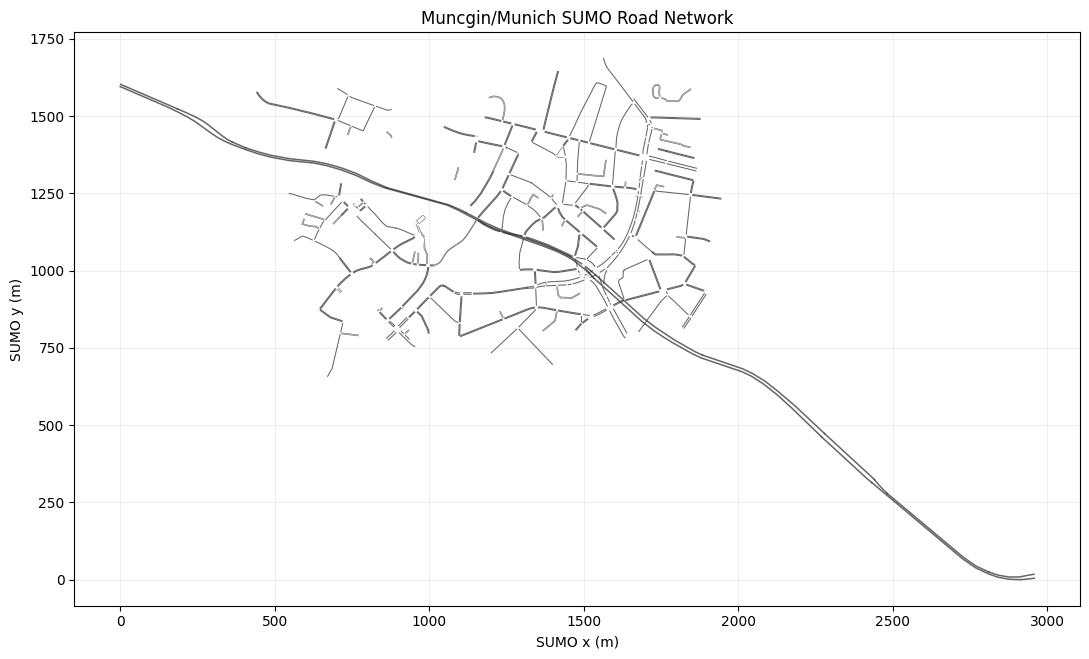

In [3]:
import sumolib

net = sumolib.net.readNet(str(NET_PATH))
fig, ax = plt.subplots(figsize=(11, 8))

for edge in net.getEdges():
    if edge.isSpecial():
        continue
    shape = edge.getShape()
    if len(shape) < 2:
        continue
    xs = [point[0] for point in shape]
    ys = [point[1] for point in shape]
    speed = edge.getSpeed()
    width = 0.45 if speed < 8 else 0.75 if speed < 14 else 1.1
    ax.plot(xs, ys, color="#333333", linewidth=width, alpha=0.75)

for idx, cfg in enumerate(gnb_configs if "gnb_configs" in globals() else []):
    ax.scatter(cfg["x"], cfg["y"], marker="^", s=120, color="#d62728", zorder=5)
    ax.text(cfg["x"] + 25, cfg["y"] + 25, f"gNB {idx}", color="#d62728", fontsize=9, weight="bold")

ax.set_title("Muncgin/Munich SUMO Road Network")
ax.set_xlabel("SUMO x (m)")
ax.set_ylabel("SUMO y (m)")
ax.set_aspect("equal", adjustable="box")
ax.grid(True, alpha=0.2)
fig.tight_layout()
plt.show()


## Create The Radio Environment And Track 5 SUMO UEs


In [4]:
SEED = 11
rng = np.random.default_rng(SEED)

gnb_configs = []
for idx, (pos, radius, carrier_id, n_prbs) in enumerate(zip(layout["gnb_positions"], layout["coverage_radius"], layout["carrier_ids"], layout["max_prbs_per_gnb"])):
    gnb_configs.append({
        "id": idx,
        "x": float(pos[0]),
        "y": float(pos[1]),
        "coverage_radius": float(radius),
        "carrier_id": int(carrier_id),
        "n_prbs": int(n_prbs),
    })

env = create_multignb_env(
    rng=rng,
    n=4,
    gnb_configs=gnb_configs,
    slots_per_step=5,
    L1_level=False,
    step_dt=1e-3,
    mobility_dt=0.0,
    radio_substeps=20,
    max_episode_steps=120,
    use_sumo_mobility=False,
)

slice_plan = ["eMBB", "eMBB", "URLLC", "URLLC", "mMTC"]
target_vehicle_ids = vehicle_ids[:5]
vehicle_to_ue = {}
ue_labels = {}
ue_slices = {}

sumo = SumoMobilityWrapper(config_path=str(SUMOCFG_PATH), sumo_binary="sumo")
sumo.start()
obs, info = env.reset(seed=SEED)
print("Target SUMO vehicles:", list(zip(target_vehicle_ids, slice_plan)))
print("Initial env info:", {k: info[k] for k in ["n_gnbs", "n_tracked_ues", "ue_per_gnb"]})


 Retrying in 1 seconds
Target SUMO vehicles: [('ue0', 'eMBB'), ('ue1', 'eMBB'), ('ue2', 'URLLC'), ('ue5', 'URLLC'), ('ue6', 'mMTC')]
Initial env info: {'n_gnbs': 4, 'n_tracked_ues': 0, 'ue_per_gnb': [0, 0, 0, 0]}


In [5]:
records = []
infos = []

def velocity_from_sumo(speed, angle):
    if angle is None:
        return 0.0, 0.0
    theta = math.radians(float(angle))
    return float(speed) * math.sin(theta), float(speed) * math.cos(theta)

def sync_sumo_to_env(sumo_state):
    vehicles = sumo_state["vehicles"]
    for idx, vehicle_id in enumerate(target_vehicle_ids):
        if vehicle_id not in vehicles:
            continue
        data = vehicles[vehicle_id]
        slice_type = slice_plan[idx]
        vx, vy = velocity_from_sumo(data.get("speed", 0.0), data.get("angle"))
        if vehicle_id not in vehicle_to_ue:
            ue_id = env.add_ue(
                x=float(data["x"]),
                y=float(data["y"]),
                vx=vx,
                vy=vy,
                slice_type=slice_type,
            )
            vehicle_to_ue[vehicle_id] = ue_id
            ue_labels[ue_id] = f"{vehicle_id}_{slice_type}"
            ue_slices[ue_id] = slice_type
        else:
            ue_id = vehicle_to_ue[vehicle_id]
            ue = env.get_ue(ue_id)
            ue.x = float(data["x"])
            ue.y = float(data["y"])
            ue.vx = vx
            ue.vy = vy

def snapshot(step, reward=0.0):
    for vehicle_id, ue_id in sorted(vehicle_to_ue.items(), key=lambda item: item[1]):
        m = env.get_ue_radio_metrics(ue_id)
        records.append({
            "step": step,
            "vehicle_id": vehicle_id,
            "ue_id": ue_id,
            "label": ue_labels[ue_id],
            "slice": ue_slices[ue_id],
            "serving_gnb": -1 if m["serving_gnb"] is None else int(m["serving_gnb"]),
            "connected": float(m["connected"]),
            "x": m["x"],
            "y": m["y"],
            "sinr_db": m["sinr_db"],
            "snr_db": m["snr_db"],
            "rx_power_dbm": m["rx_power_dbm"],
            "interference_dbm": m["interference_dbm"],
            "allocated_prbs": m["allocated_prbs"],
            "mcs": m["mcs"],
            "queue": m["queue"],
            "throughput": m["throughput"],
            "served_bits": m["served_bits"],
            "delay_steps": m["delay_steps"],
            "reward": reward,
        })

N_STEPS = 80
try:
    for step in range(N_STEPS):
        sumo_state = sumo.step()
        sync_sumo_to_env(sumo_state)
        obs, reward, terminated, truncated, info = env.step(0)
        infos.append(info)
        snapshot(step, reward)
        if len(vehicle_to_ue) >= 5 and step % 10 == 0:
            print("step", step, "mapped", vehicle_to_ue, "ue_per_gnb", info["ue_per_gnb"])
finally:
    sumo.close()

print("Mapped SUMO vehicles to UEs:", vehicle_to_ue)
print("Collected rows:", len(records))
assert len(vehicle_to_ue) == 5, "Did not see all 5 target vehicles during the run"


step 10 mapped {'ue0': 0, 'ue1': 1, 'ue2': 2, 'ue5': 3, 'ue6': 4} ue_per_gnb [0, 0, 4, 1]
step 20 mapped {'ue0': 0, 'ue1': 1, 'ue2': 2, 'ue5': 3, 'ue6': 4} ue_per_gnb [0, 0, 4, 1]
step 30 mapped {'ue0': 0, 'ue1': 1, 'ue2': 2, 'ue5': 3, 'ue6': 4} ue_per_gnb [0, 0, 4, 1]
step 40 mapped {'ue0': 0, 'ue1': 1, 'ue2': 2, 'ue5': 3, 'ue6': 4} ue_per_gnb [0, 0, 4, 1]
step 50 mapped {'ue0': 0, 'ue1': 1, 'ue2': 2, 'ue5': 3, 'ue6': 4} ue_per_gnb [0, 0, 4, 1]
step 60 mapped {'ue0': 0, 'ue1': 1, 'ue2': 2, 'ue5': 3, 'ue6': 4} ue_per_gnb [0, 0, 4, 1]
step 70 mapped {'ue0': 0, 'ue1': 1, 'ue2': 2, 'ue5': 3, 'ue6': 4} ue_per_gnb [0, 0, 4, 1]
Mapped SUMO vehicles to UEs: {'ue0': 0, 'ue1': 1, 'ue2': 2, 'ue5': 3, 'ue6': 4}
Collected rows: 386


## Plot Radio Metrics


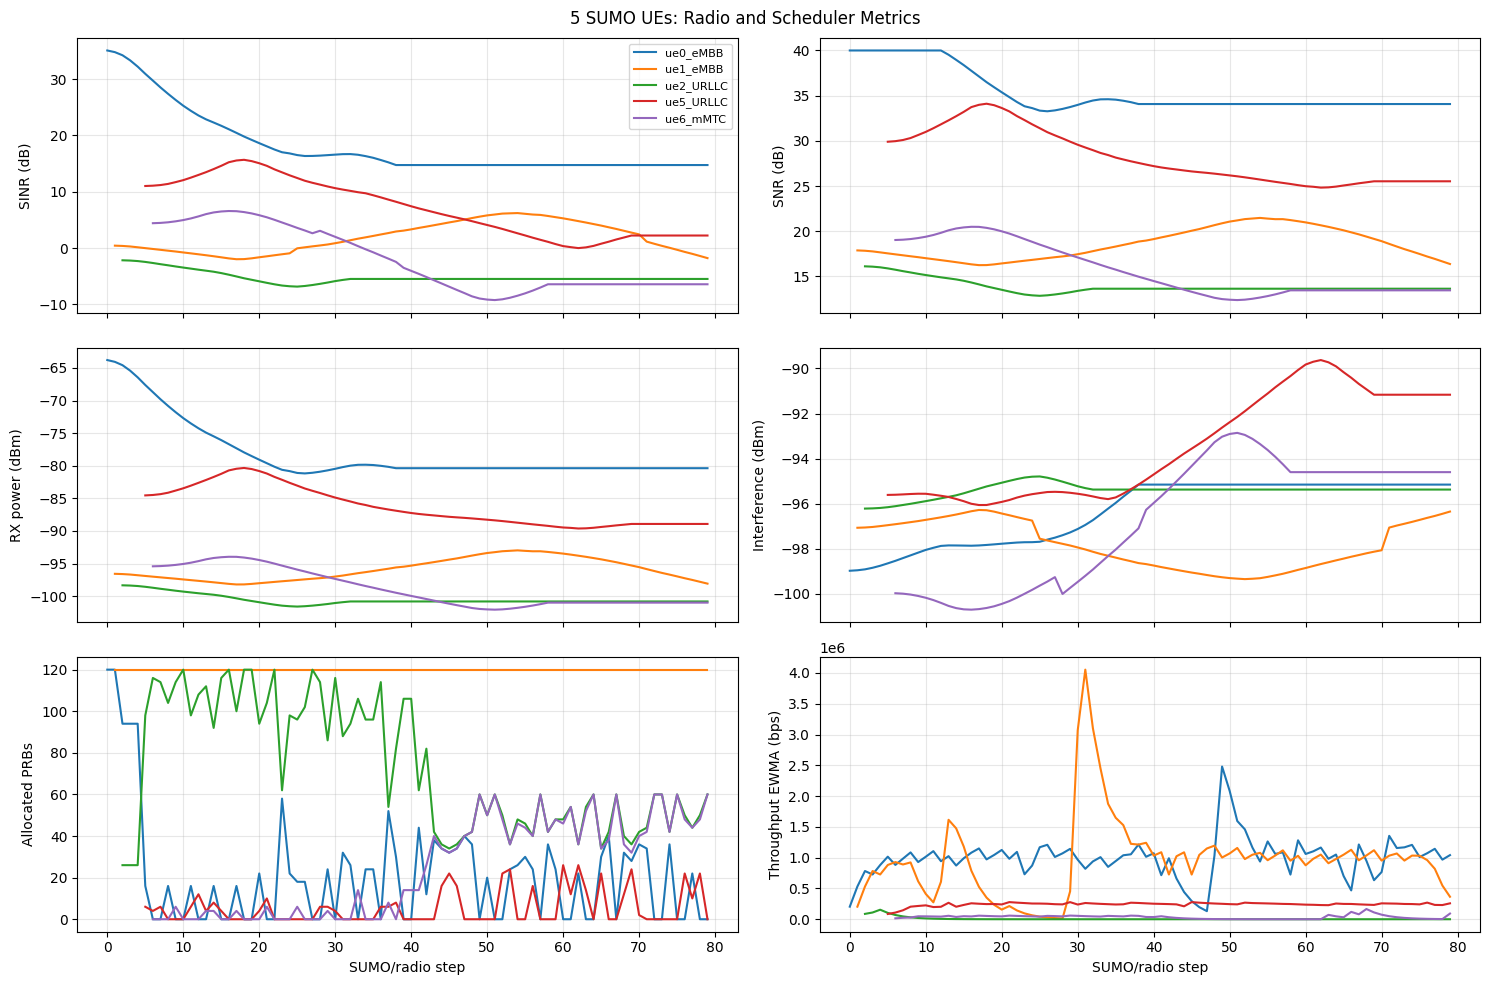

In [6]:
def series(label, key):
    rows = [row for row in records if row["label"] == label]
    return np.array([row["step"] for row in rows]), np.array([row[key] for row in rows], dtype=float)

labels = [ue_labels[ue_id] for ue_id in sorted(ue_labels)]
fig, axes = plt.subplots(3, 2, figsize=(15, 10), sharex=True)
plots = [
    ("sinr_db", "SINR (dB)"),
    ("snr_db", "SNR (dB)"),
    ("rx_power_dbm", "RX power (dBm)"),
    ("interference_dbm", "Interference (dBm)"),
    ("allocated_prbs", "Allocated PRBs"),
    ("throughput", "Throughput EWMA (bps)"),
]
for ax, (key, ylabel) in zip(axes.flat, plots):
    for label in labels:
        x, y = series(label, key)
        ax.plot(x, y, label=label)
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)
axes[0, 0].legend(fontsize=8)
axes[-1, 0].set_xlabel("SUMO/radio step")
axes[-1, 1].set_xlabel("SUMO/radio step")
fig.suptitle("5 SUMO UEs: Radio and Scheduler Metrics")
fig.tight_layout()
plt.show()


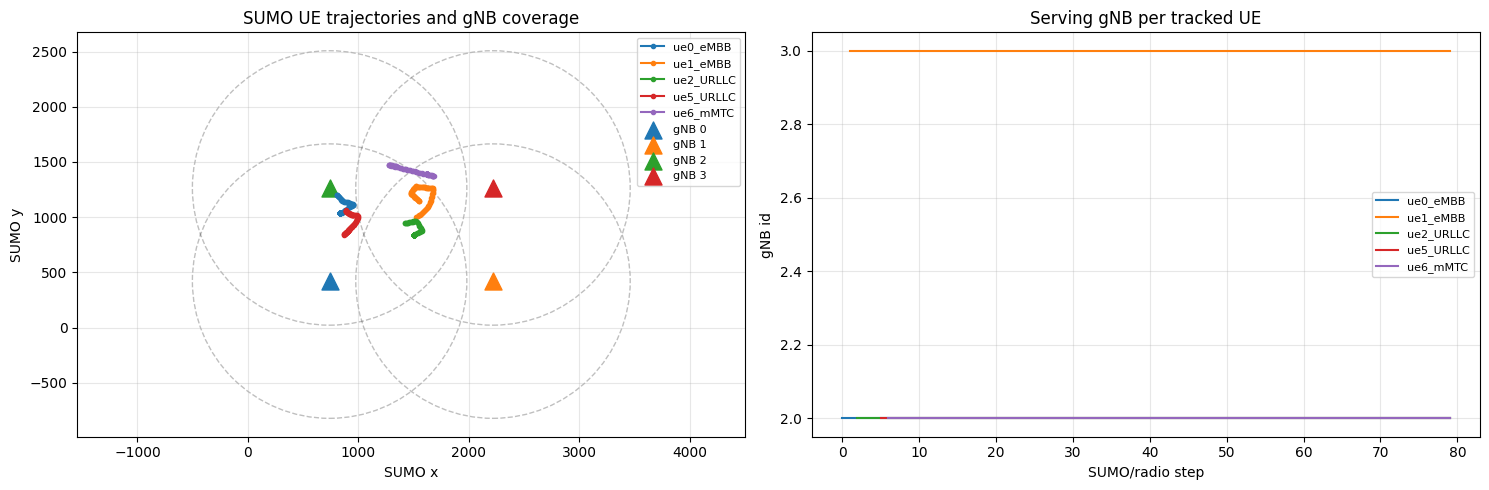

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for label in labels:
    rows = [row for row in records if row["label"] == label]
    axes[0].plot([row["x"] for row in rows], [row["y"] for row in rows], marker=".", label=label)
    x, y = series(label, "serving_gnb")
    axes[1].step(x, y, where="post", label=label)

for cfg in gnb_configs:
    axes[0].scatter(cfg["x"], cfg["y"], marker="^", s=150, label=f"gNB {cfg['id']}")
    circle = plt.Circle((cfg["x"], cfg["y"]), cfg["coverage_radius"], fill=False, linestyle="--", alpha=0.25)
    axes[0].add_patch(circle)

axes[0].set_title("SUMO UE trajectories and gNB coverage")
axes[0].set_xlabel("SUMO x")
axes[0].set_ylabel("SUMO y")
axes[0].axis("equal")
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=8)

axes[1].set_title("Serving gNB per tracked UE")
axes[1].set_xlabel("SUMO/radio step")
axes[1].set_ylabel("gNB id")
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()


## Final Snapshot


In [8]:
for vehicle_id, ue_id in sorted(vehicle_to_ue.items(), key=lambda item: item[1]):
    print(vehicle_id, ue_labels[ue_id], env.get_ue_radio_metrics(ue_id))

env.close()


ue0 ue0_eMBB {'ue_id': 0, 'serving_gnb': 2, 'connected': True, 'x': 836.9169754731175, 'y': 1034.0076143047106, 'vx': -11.531792583673685, 'vy': -8.725660029268923, 'queue': 0.0, 'throughput': 1041289.6661408378, 'delay_steps': 0.0, 'new_bits': 0.0, 'served_bits': 0.0, 'scheduled_bits': 0.0, 'dropped_bits': 0.0, 'total_bits_arrived': 1596000.0, 'total_bits_dropped': 0.0, 'traffic_packet_size_bits': 12000.0, 'offered_bit_rate': 1000000.0, 'allocated_prbs': 0, 'rx_probability': 0.0, 'mcs': 21, 'spectral_efficiency': 4.5, 'scheduled_sinr_db': 17.13962127489089, 'scheduler_mode': 'mcs_pf_csv_fading', 'snr_db': 34.073692711454186, 'sinr_db': 14.730783618224223, 'rx_power_dbm': -80.37358223751275, 'noise_dbm': -114.44727494896694, 'interference_dbm': -95.15518553363002, 'target_gnb': None, 'ho_pending': False, 'ho_candidate': None, 'ho_counter': 0, 'environment_loss_db': 0.0}
ue1 ue1_eMBB {'ue_id': 1, 'serving_gnb': 3, 'connected': True, 'x': 1524.6916772765694, 'y': 1003.5600419825244, 'vx'